<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW3_Classification_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 3. Линейная классификация (base)**

### **Оценивание и штрафы**

С наступающим новым годом, друзья! Магистратура бежит быстро и мы бежим очень быстро, а зима — то время, когда хотелось бы бежать чуть медленнее. Поэтому это домашнее задание мы сделали сильно короче от его начальной версии!

Как всегда, каждая из задач имеет «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

В задании две части:

- Часть 1: написание логистической регрессии своими руками — уверенны, логлосс вы уже знаете как свои пять пальцев.
- Часть 2: решение задачи классификации на текстах.

In [1]:
%pylab inline
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, roc_auc_score

Populating the interactive namespace from numpy and matplotlib


In [2]:
RANDOM_STATE = 42

In [3]:
#from google.colab import drive # Если вы работаете в коллабе
#drive.mount('/content/drive')

# **Часть 1. Логистическая регрессия своими руками (5 баллов)**

Логистическая регрессия — безумно важная и удобная модель для понимания начальных концепций. Вы много практиковались с выведением формулы градиента логлосса, шага спуска, а в прошлом дз сделали SGD. Давайте сделаем ещё шаг вперед — и реализуем логистическую регрессию своими руками.

На практике, часто хватает алгоритмов из коробки. Но иногда очень удобно сделать свой алгоритм.

## **Теоретическая сноска: почему LogLoss'а так много**

Почти наверное (в математике это значит, во всех случаях, кроме множества размером 0) логлосс набил оскомину за несколько заданий. Давайте посмотрим на него ещё раз:

В логистической регрессии функция потерь

$$\text{LogLoss}(y, \hat{p}) = -\left(y\log \hat{p} + (1-y)\log (1-\hat{p})\right)$$

Зачем мы так долго с ней возимся?

#### **Пункт 1.**
Во-первых, это **следствие максимизации правдоподобия** при биномиальной модели.

Если считать, что целевая переменная (Y\in{0,1}) распределена как

$$P(Y=1 \mid x) = \hat{p}(x), \qquad P(Y=0\mid x) = 1-\hat{p}(x),$$
то правдоподобие выборки ( (x_i, y_i) )\ равно
$$L = \prod_{i=1}^n \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}.$$

Максимизация $\log L$ эквивалентна минимизации LogLoss.
Таким образом, LogLoss — **единственная функция потерь, полностью согласованная с вероятностной моделью логистической регрессии**.

#### **Пункт 2.**

Во-вторых, логлосс поможет нам в будущем понять другие функции потерь. Так, например LogLoss является частным случаем **кросс-энтропии между истинным распределением и предсказанным**.

Для двух распределений $p$ (истинного) и $q$ (предсказанного) кросс-энтропия определяется как

$$H(p,q) = -\sum_{k} p(k)\log q(k).$$

В бинарном случае истинное распределение дискретно:

$$p = (y, 1-y), \qquad q = (\hat{p}, 1-\hat{p}),$$
и подстановка даёт

$$H(p,q) = -\left[y\log \hat{p} + (1-y)\log (1-\hat{p})\right] = \text{LogLoss}.$$


В общем, любим, жалуем и реализуем.




### **Задание 1. Реализуйте класс логистической регрессии, обучаемой с помощью:**

**Задание 1.1 (1.5 балла). Градиентного спуска**

**Задание 1.2 (1.5 балла). Стохастического градиентного спуска**

До этого вы писали код без ограничений. Здесь же необходимо соблюдать следующие условия:

- Градиентный спуск необходимо записать в векторном виде;
- Циклы средствами python допускается использовать только для итераций градиентного спуска;

**Класс градиентного спуска должен:**
- В качестве критерия останова использовать (одновременно):
  - проверку на евклидову норму разности весов на двух соседних итерациях задаваемого параметром `tolerance`;
  - достижение максимального числа итераций, задаваемого параметром `max_iter`.
- Обладать атрибутом `loss_history`. В нём после вызова метода fit должны содержаться значения функции потерь для всех итераций, начиная с первой (до совершения первого шага по антиградиенту). Данный атрибут необходим, чтобы проследить, что оптимизационный процесс действительно сходится;
- Инициализировать веса случайным образом или нулевым вектором (на ваш выбор).

Полезно [почитать](https://scikit-learn.org/stable/developers/develop.html).

**Шаблон класса описан ниже, вам нужно реализовать каждую из заготовленных функций.**

**ВАЖНО!** Мы заполняем данный шаблон, даже если он нам не нравится. Менять структуру класса и писать по-своему запрещено - за это будут сняты баллы.

In [4]:
import numpy as np
from typing import Optional
from sklearn.base import BaseEstimator


class LogReg(BaseEstimator):
    def __init__(
        self,
        gd_type: str = 'stochastic',
        tolerance: Optional[float] = 1e-4,
        max_iter: Optional[int] = 1000,
        w0: Optional[np.ndarray] = None,
        eta: float = 1e-2,
    ) -> None:
        """
        gd_type: 'full' or 'stochastic'
        tolerance: for stopping gradient descent
        max_iter: maximum number of steps in gradient descent
        w0: np.array of shape (d) — init weights
        eta: learning rate
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.w = None
        self.eta = eta
        self.loss_history = []
        self._is_fitted = False

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """

        ell, d = X.shape

        # Инициализируем первоначальный вектор весов
        if not self.w:
            self.w = np.zeros(X.shape[1])

        for _ in range(self.max_iter):

            # Первоначальный loss
            loss = self.calc_loss(X, y)
            self.loss_history.append(loss)

            w_old = self.w.copy()

            if self.gd_type == 'full':
                grad = self.calc_gradient(X, y)
                self.w -= self.eta * grad

            elif self.gd_type == 'stochastic':
                # Сделаем с подбором по одному обучающему примеру
                idx = np.random.randint(ell)
                Xi = X[idx:idx + 1]  # (1, d)
                yi = y[idx:idx + 1]  # (1,)
                grad = self.calc_gradient(Xi, yi)
                self.w -= self.eta * grad

            # остановка
            if np.linalg.norm(self.w - w_old) < self.tolerance:
                break

        self._is_fitted = True

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if not self._is_fitted:
            raise ValueError('Model was not fitted yet.')
        p = self.sigmoid(X @ self.w)
        q = 1 - p
        return np.column_stack((q, p))

    def predict(self, X: np.ndarray) -> np.ndarray:
        if not self._is_fitted:
            raise ValueError('Model was not fitted yet.')
        return np.argmax(self.predict_proba(X), axis=1)

    def sigmoid(self, x: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-x))

    def calc_gradient(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        """
        X: np.array of shape (ell, d) (ell can be equal to 1 if stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """
        # В качестве лосса тут рассматриваем LogLoss !
        p = self.sigmoid(X @ self.w)
        grad = X.T @ (p - y) / X.shape[0]
        return grad

    def calc_loss(self, X: np.ndarray, y: np.ndarray) -> float:
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """
        p = self.sigmoid(X @ self.w)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


Теперь проверим работу вашего класса на синтетических данных.

In [5]:
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=100000,
    n_features=20,
    n_informative=2,
    random_state=RANDOM_STATE,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### **Задание 2 (0.6 балла)**

Теперь давайте тестировать модель.
[x] Обучите свою логистическую регрессию на синтетических данных (0.2 балла) — на полном GD и SGD;
[x] Cравните результат с моделью из библиотеки. Посчитайте roc-auc, accuracy, постройте ROC и PR кривые. , оцените разницу в производительности моделей по метрикам качества. Ответьте на вопросы:
- Какая показывает лучший результат? Почему?
- Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели? Для ответа на этот вопрос вам может пригодитться [документация](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Её мы изучаем всегда, чтобы понимать тонкости реализации какого-либо метода в библиотеке. (0.4 балла)

In [6]:
lr_sgd = LogReg(gd_type='stochastic')
lr_sgd.fit(X_train, y_train)

lr_full = LogReg(gd_type='full')
lr_full.fit(X_train, y_train)


,gd_type,'full'
,tolerance,0.0001
,max_iter,1000
,w0,None
,eta,0.01


In [7]:
# Ваш код здесь
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)


def lr_profiler(model, X_test, y_test, model_name='Model'):
    proba = model.predict_proba(X_test)[:, 1]

    preds = (proba >= 0.5).astype(int)

    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, preds)

    print(f'====== {model_name} ======')
    print(f'ROC-AUC:   {auc:.4f}')
    print(f'Accuracy:  {acc:.4f}')
    print()

    # ---- ROC Curve ----
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {model_name}')
    plt.legend()
    plt.grid()
    plt.show()

    # ---- PR Curve ----
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=model_name)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve: {model_name}')
    plt.grid()
    plt.legend()
    plt.show()

    return {'roc_auc': auc, 'accuracy': acc}


results = {}

====== CustomLogisticRegressionSGD ======
ROC-AUC:   0.9388
Accuracy:  0.8660



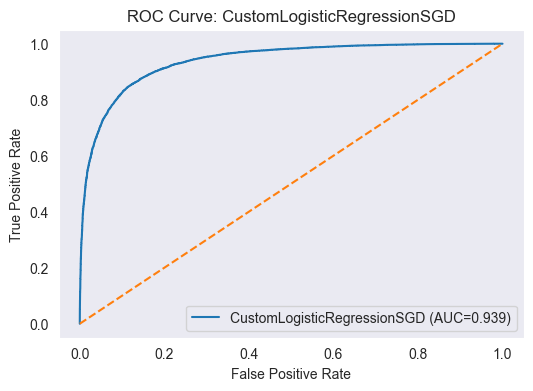

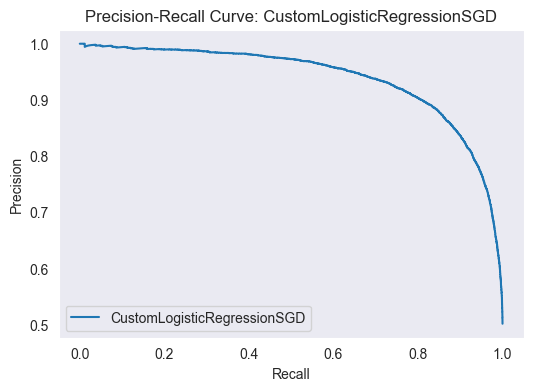

In [9]:
MODEL_NAME = 'CustomLogisticRegressionSGD'
results[MODEL_NAME] = lr_profiler(lr_full, X_test, y_test, MODEL_NAME)

====== CustomLogisticRegression ======
ROC-AUC:   0.9361
Accuracy:  0.8616



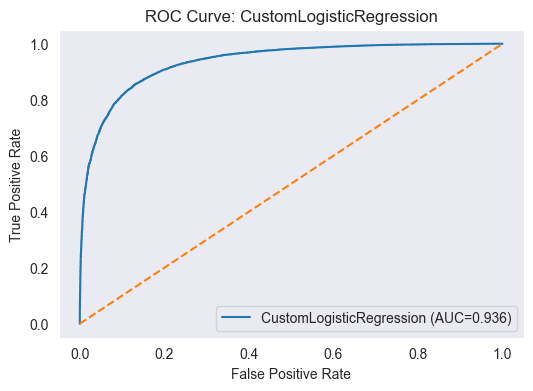

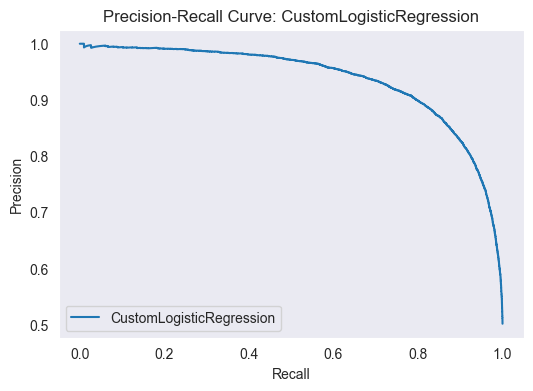

In [10]:
MODEL_NAME = 'CustomLogisticRegression'
results[MODEL_NAME] = lr_profiler(lr_sgd, X_test, y_test, MODEL_NAME)

====== SklearnLogisticRegression ======
ROC-AUC:   0.9399
Accuracy:  0.8681



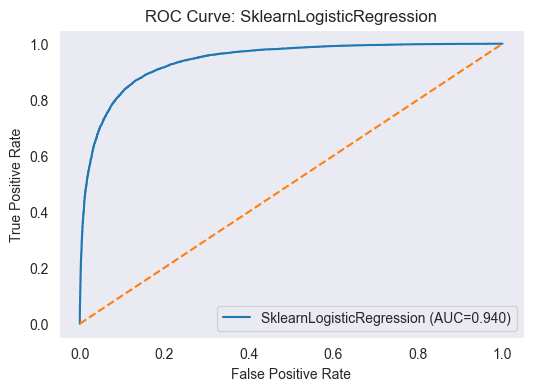

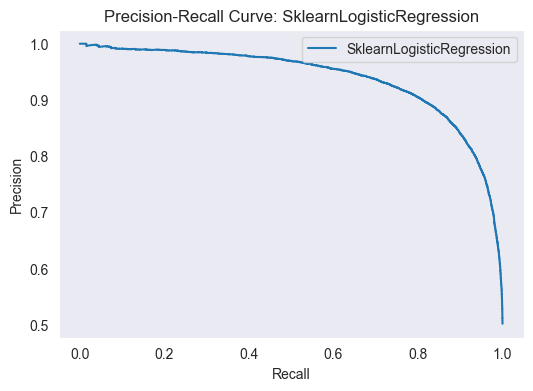

In [11]:
MODEL_NAME = 'SklearnLogisticRegression'
results[MODEL_NAME] = lr_profiler(lr, X_test, y_test, 'SklearnLogisticRegression')

In [12]:
results_df = pd.DataFrame.from_dict(results).T
results_df.sort_values(by=['roc_auc'], ascending=False)

,roc_auc,accuracy
SklearnLogisticRegression,0.939892,0.868100
CustomLogisticRegressionSGD,0.938850,0.866033
CustomLogisticRegression,0.936070,0.861633


Какая показывает лучший результат? Почему?

## Анализ результатов

Лучший результат показывает модель из Sklearn с дефолтными параметрами - у неё больше `roc_auc`. Стоит отметить, что наши модели все находятся примерно на одном уровне по метрикам и процента.


## Отличие модели из sklearn от реализованной модели

- Наличие регуляризации. По умолчанию используется - L2
- Более продвинутые оптимизаторы. В sklearn можно использовать более оптимальные алгоритмы поиска минимума, как по памяти (L-BFGS), так и по  

*В качестве дефолтного используется L-BFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno)) - которые более эффективен на большом датасете и большом объеме фичей. Эффективен тем, что не вычисляет весь гессиан. Но принципиально от нашей реализации (отсутствует переменный шаг ) он не отличается

Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели? Для ответа на этот вопрос вам может пригодитться [документация](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Её мы изучаем всегда, чтобы понимать тонкости реализации какого-либо метода в библиотеке. (0.4 балла)

### **Задание 3 (0.4 балла)**

Для трех полученных моделей, визуализируйте прогнозы по данным на тестовой выборке. Для этого:
- получите прогнозы;
- сомжите данные, используя PCA. Не забудьте, что PCA полагает нулевое среднее и единичную дисперсию;
- покрасьте данные по прогнозам.

Как различаются графики для трёх моделей? И различаются ли?

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)  # данные уже ранее были обработаны sklearn.StandardScaler

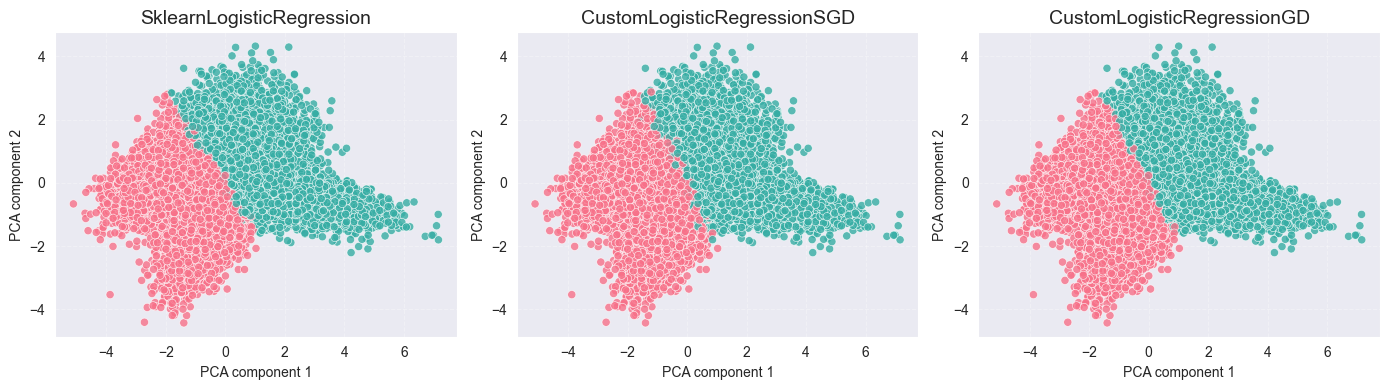

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    'SklearnLogisticRegression': lr,
    'CustomLogisticRegressionSGD': lr_sgd,
    'CustomLogisticRegressionGD': lr_full,
}

predictions_data = {}

for model_name, model in models.items():
    proba = model.predict_proba(X_test)
    preds = (proba[:, 1] >= 0.5).astype(int)
    predictions_data[model_name] = preds

plt.figure(figsize=(14, 4))

for i, (title, preds) in enumerate(predictions_data.items()):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(
        x=X_test_pca[:, 0],
        y=X_test_pca[:, 1],
        hue=preds,
        palette="husl",
        s=35,
        alpha=0.8,
        legend=False
    )

    plt.title(title, fontsize=14)
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


## Интерпретация графиков


### Общее описание

- С помощью PCA-метода мы понизили размерность наших фичей до 2-х и отобразили их на плоскости.
- Графики отличаются незначительно. Все 3 модели провели достаточно близкие границы между классами. 
- Стоит отметить, что так как мы обучали линейную модель, то и плоскости мы видим прямую границу между классами

### Отличия

- Наиболее похоже границы разделения у  SklearnLogisticRegression & CustomLogisticRegressionGD (обычный градиентный спуск). Оба тренируются на полной выборке, однако функция поиска градиента в sklearn имеет другую реализацию для эффективности по памяти.
- В кастомном стохастическом градиентном спуске мы применили подбор весов для единичного объект, что могло сказать на качестве финальной моделе. В окрестности границы мы видим пару примеров, где данная модель промахнулась

# **Часть 2. Обучение моделей на текстовых данных. (5 баллов)**

 ### **Подготовка данных из реального мира.**

Ещё одна прелесть простых моделей — возможность решать с ними неструктурированные (изначально не табличные) задачи. Давайте посмотрим на это в действии на примере текстов.


Загрузите данные с конкурса  [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data?select=train.csv) (вам нужна только обучающая выборка, файл `train.csv`). Задача состоит в определении постов, сообщающих о чрезвычайной ситуации. В рамках домашнего задания, этот набор данных будет отличным полем для тренировки в обработке признаков.

In [15]:
from sklearn.model_selection import train_test_split

PATH = 'tweets.csv'
data = pd.read_csv(PATH)

data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### **Задание 10. Базовая предобработка (1.5 балла).**

- Выведите на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их пустой строкой (0.2 балла).

In [16]:
print('Пропуски в данных')
data.isnull().sum()

Пропуски в данных


id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [17]:
# Заполнение пропусков
data = data.fillna('')
data.isnull().sum()

id          0
keyword     0
location    0
text        0
target      0
dtype: int64

- Проанализируйте количество уникальных значений в столбцах, опустив `text`. Сделайте выводы. (0.5 балла)

In [18]:
cols = list(data.columns)
cols.remove('text')

for col in cols:
    print('Column: ', col)
    print('Unique values: ', data[col].nunique())
    print('=' * 20)
    # print('Unique values: ', data[col].unique())

Column:  id
Unique values:  7613
Column:  keyword
Unique values:  222
Column:  location
Unique values:  3342
Column:  target
Unique values:  2


- Проанализируйте соотношение классов в целевой переменной. Какое оно? Выберите метрику, с помощью которой будете оценивать модель.  (0.5 балла)

In [19]:
data['target'].value_counts(normalize=True)

target
0    0.57034
1    0.42966
Name: proportion, dtype: float64

### Комментарий по балансу классов
Почти 43% объектов принадлежат к тестовому классу. Это значит, что классы не полностью сбалансированы по количеству экземпляров. Тем не менее, они отличаются не в разы, что позволяет нам говорить об "относительном" балансе.


# Выбор метрики

Для решения задачи классификации нам подходят несколько метрик качества:

- `Accuracy` - подсчет процента верных попаданий в класс
- `Precision` - точность определения классов
- `Recall` - полнота определения объектов целевого класса
- `F1-Score` - среднегармоническое между `Precision` & `Recall`

В качестве основной метрики для нашего классификатора мы предлагаем использовать `F1-Score`, которая является комплексной производной от `Precision` & `Recall`. Это позволит нам сохранить баланс между точностью и полнотой предсказаний.

В качестве вспомогательных выведем также Precision, Recall и accuracy

In [20]:
from dataclasses import dataclass
import time


@dataclass
class Timer:
    def __init__(self, title: str = 'Timer'):
        self._start_time = None
        self.title = title

    def start(self):
        """Start a new timer"""
        if self._start_time is not None:
            raise ValueError(f'Timer is running. Use .stop() to stop it')

        self._start_time = time.perf_counter()

    def stop(self):
        """Stop the timer, and report the elapsed time"""
        if self._start_time is None:
            raise ValueError('Timer is not running. Use .start() to start it')

        elapsed_time = time.perf_counter() - self._start_time
        self._start_time = None
        print(f'[{self.title}] Elapsed time: {elapsed_time:0.4f} seconds')

    def __enter__(self):
        """Start a new timer as a context manager"""
        self.start()
        return self

    def __exit__(self, *exc_info):
        """Stop the context manager timer"""
        self.stop()


In [50]:
# Допишем класс для выведения вспомогательной информации
from typing import Any
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

np.set_printoptions(suppress=True)


def plot_confusion_matrix(y_pred, y_test, model_name: str = 'MyModel') -> None:
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Raw CM
    sns.heatmap(
        cm, annot=True, fmt='g', cmap='Blues',
        cbar=False, ax=ax[0], annot_kws={'size': 14}
    )
    ax[0].set_title(f'{model_name} — Confusion Matrix (Counts)', fontsize=16)
    ax[0].set_xlabel('Predicted', fontsize=14)
    ax[0].set_ylabel('Actual', fontsize=14)

    # Normalized CM
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        cbar=False, ax=ax[1], annot_kws={'size': 14}
    )
    ax[1].set_title(f'{model_name} — Confusion Matrix (Normalized)', fontsize=16)
    ax[1].set_xlabel('Predicted', fontsize=14)
    ax[1].set_ylabel('Actual', fontsize=14)

    plt.tight_layout()
    plt.show()


class Evaluator:
    model_metrics = {}

    def eval(self, estimator, X_text, y_test, model_name: str = 'Model') -> tuple[dict[str, Any], np.array]:
        metrics = {}
        y_pred = estimator.predict(X_text)

        plot_confusion_matrix(y_pred, y_test, model_name=model_name)

        metrics['accuracy'] = accuracy_score(y_test, y_pred)
        metrics['precision'] = precision_score(y_test, y_pred)
        metrics['recall'] = recall_score(y_test, y_pred)
        metrics['f1'] = f1_score(y_test, y_pred)
        print(metrics)
        self.model_metrics[model_name] = metrics
        return metrics, y_pred

    def get_results(self) -> pd.DataFrame:
        stat_df = pd.DataFrame.from_dict(self.model_metrics, orient="index")
        stat_df.index.rename("model", inplace=True)
        return stat_df.reset_index()


evaluator = Evaluator()

- Объедините все три текстовых столбца в один для baseline (вам поможет конкатенация строк) (0.3 балла)

In [51]:
# Я что-то делаю, но не знаю зачем я это делаю...

data_new = data.copy(deep=True)
data_new['text'] = data_new['keyword'] + '_' + data_new['location'] + ' ' + data_new['text']

- Наконец, поделите данные на тренировочную и тестовую выборки. (0.2 балла)

In [52]:
X = data_new['text']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Задание 11. Базовые модели. (1 балл).**

Данные, собираемые с сайтов, часто содержат мусор не информативный для моделей. Посмотрите, какого качества и насколько разнообразны данные здесь. Для этого:
- Примените CountVectorizer из sklearn к сырым даным. Какого размера получилась матрица? (0.3 балла)

In [53]:
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(
    analyzer='word',
    stop_words='english',
)

X_train_raw_vec = count_vec.fit_transform(X_train)
print('Train Shape: ', X_train_raw_vec.shape)
X_test_raw_vec = count_vec.transform(X_test)
print('Test Shape: ', X_test_raw_vec.shape)

Train Shape:  (5329, 20711)
Test Shape:  (2284, 20711)


- Обучите логистическую регрессию на полученном наборе. Модель возьмите из библиотеки. Какое качество по выбранной вами метрике у модели получилось на тестовых данных? (0.3 балла)

In [54]:
from sklearn.linear_model import LogisticRegression

logreg_base = LogisticRegression()

with Timer('Logistic Regression'):
    logreg_base.fit(X_train_raw_vec, y_train)


[Logistic Regression] Elapsed time: 0.0402 seconds


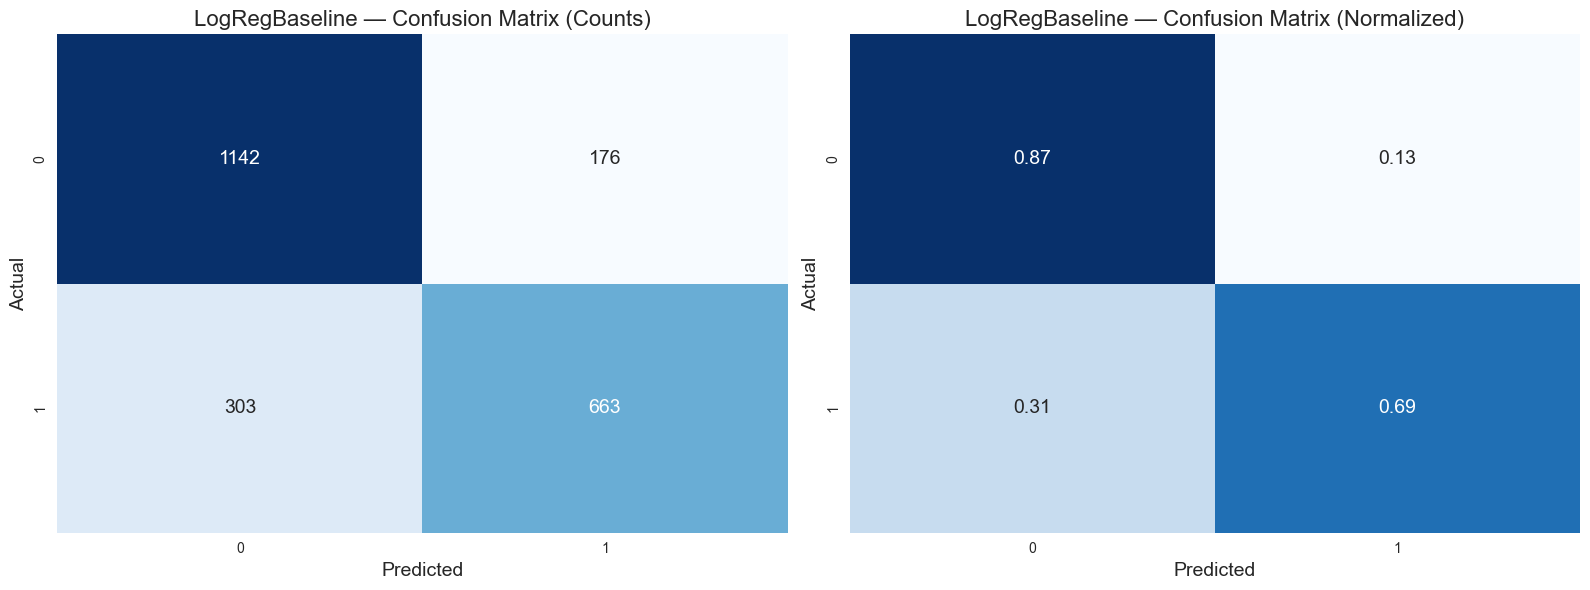

{'accuracy': 0.7902802101576182, 'precision': 0.7902264600715138, 'recall': 0.6863354037267081, 'f1': 0.7346260387811634}


In [55]:
metrics, y_pred = evaluator.eval(logreg_base, X_test_raw_vec, y_test, model_name='LogRegBaseline')

## Результаты обучения

Наша модель на бейзлайне показала достаточно неплохой результат по метрикам:

- f1': 0.7346260387811634
- 'precision': 0.7902264600715138
- 'recall': 0.6863354037267081,
- 'accuracy': 0.7902802101576182

### Интерпретация

- По целевой метрике f1 - мы достигли 73%. 
- Различие между precision и recall более существенны. Precision - 79%, recall - 68%. 
- Такое отличие может быть объяснено дисбалансом классов (43 (1) на 57(0)), однако значения выше это значения показывают, что мы уже лучше рандомайзера
- Наша модель достаточно точно классифицирует тексты, но не все из целевых попали в нужный класс 

- Обучите SVC на тех же данных с гиперпараметрами по умолчанию. Измерьте качество на тестовых данных и опишите результат. Проанализируйте качество и скорость обучения.(0.4 балла)

In [56]:
from sklearn.svm import SVC

svc_base = SVC()

with Timer('SVC'):
    svc_base.fit(X_train_raw_vec, y_train)

[SVC] Elapsed time: 1.4461 seconds


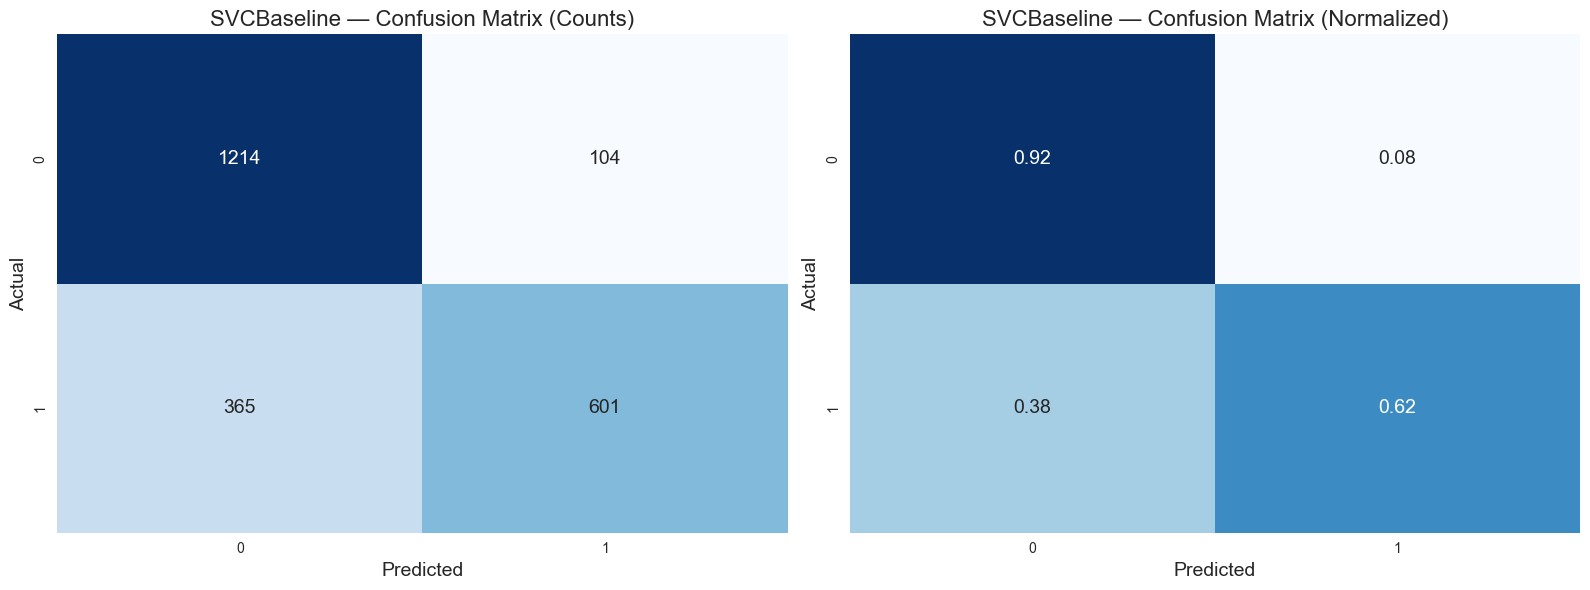

{'accuracy': 0.7946584938704028, 'precision': 0.8524822695035461, 'recall': 0.6221532091097308, 'f1': 0.7193297426690605}


In [57]:
metrics, y_pred = evaluator.eval(svc_base, X_test_raw_vec, y_test, model_name='SVCBaseline')


## Результат обучения SVC

Результаты обучения:

- 'f1': 0.7193297426690605
- 'precision': 0.8524822695035461
- 'recall': 0.6221532091097308
- 'accuracy': 0.7946584938704028


### Интерпретация

- По целевой метрике f1 - мы достигли 72% 
- Различие между precision и recall более существенны. Precision - 85%, recall - 62%. 
- Наша модель прибавила в точности, но потеряла в полноте. Принимая факт дисбаланса классов, она более склонна к тому, что бы "исключать" наш класс. 


## Сводная по метрикам

In [58]:
evaluator.get_results()

,model,accuracy,precision,recall,f1
0,LogRegBaseline,0.790280,0.790226,0.686335,0.734626
1,SVCBaseline,0.794658,0.852482,0.622153,0.719330


### **Задание 12. Улучшение базовых моделей за счет данных. (0.3 балла).**

- Подберите гиперпараметры CountVectorizer так, чтобы признаков было минимум в 4 раза меньше, чем объектов, а качество модели при этом изменилось не более чем на $\pm 0.07$. Опишите подобранные гиперпараметры и на что они влияют.

Обучайте и логистическую регрессию, и SVC.

In [59]:
cnt_vectorizer = CountVectorizer(
    analyzer='word',
    stop_words='english',
    # Слово не более чем в 99% по df
    max_df=0.95,
    # Токен как минимум в 10 текстах
    min_df=10,
)

X_train_raw_vec = cnt_vectorizer.fit_transform(X_train, )
print('Train Shape: ', X_train_raw_vec.shape)
assert X_train_raw_vec.shape[0] / X_train_raw_vec.shape[1] > 4, 'Num features is greater than 4'

X_test_raw_vec = cnt_vectorizer.transform(X_test)
print('Test Shape: ', X_test_raw_vec.shape)

Train Shape:  (5329, 1138)
Test Shape:  (2284, 1138)


In [60]:
from sklearn.linear_model import LogisticRegression

lr_raw = LogisticRegression()

with Timer('Logistic Regression'):
    lr_raw.fit(X_train_raw_vec, y_train)


[Logistic Regression] Elapsed time: 0.0099 seconds


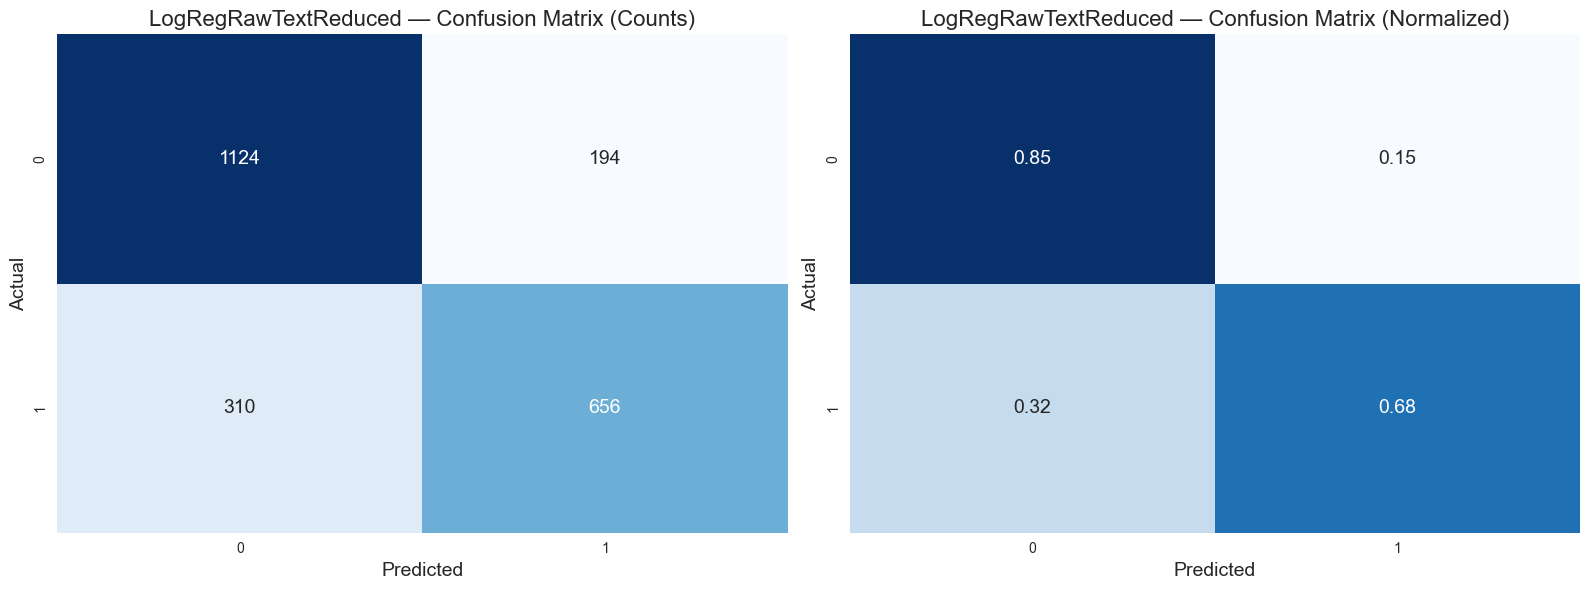

{'accuracy': 0.7793345008756567, 'precision': 0.7717647058823529, 'recall': 0.6790890269151139, 'f1': 0.7224669603524229}


In [61]:
metrics, y_pred = evaluator.eval(lr_raw, X_test_raw_vec, y_test, model_name='LogRegRawTextReduced')

In [62]:
# повторное обучение SVC
from sklearn.svm import SVC

svc_raw = SVC()

with Timer('SVC'):
    svc_raw.fit(X_train_raw_vec, y_train)

[SVC] Elapsed time: 0.7343 seconds


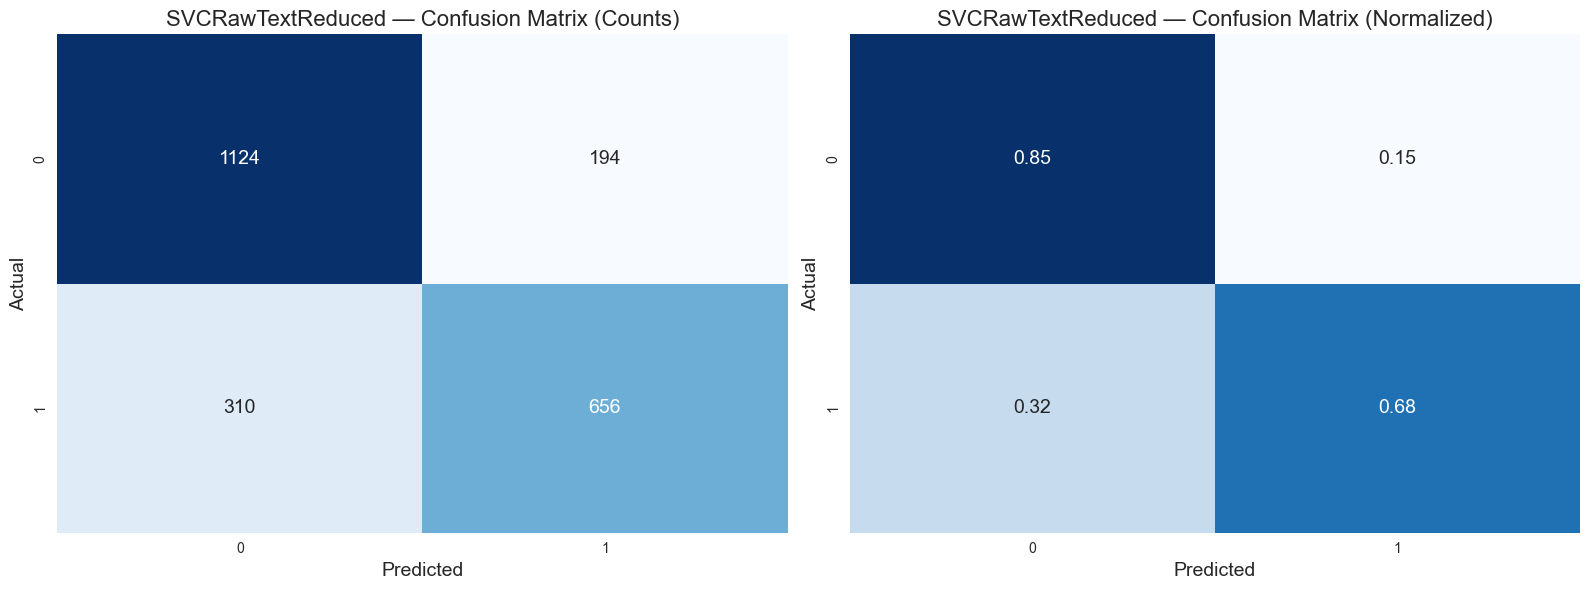

{'accuracy': 0.7793345008756567, 'precision': 0.7717647058823529, 'recall': 0.6790890269151139, 'f1': 0.7224669603524229}


In [63]:
metrics, y_pred = evaluator.eval(lr_raw, X_test_raw_vec, y_test, model_name='SVCRawTextReduced')

# Интерпретация


- Нам удалось сократить количество используемых фичей почти в 20 раз (20711 против 1138)
- Для модели LogisticRegression качество по метрике F1 ухудшилось на 1.8% (72.2% против 73.5%)
- Для модели SVC качество по метрике F1 улучшилось на 0.2% - что можно считать погрешность. То есть, качество не ухудшилось
- По вспомогательным метрикам заметна общая тенденция на снижение precision, но повышение recall. 

Предположите удаление самых высокочастотных топиков обрезало общие токены для двух классов, а низкочастотных - удалило лишние веса, которые смещали фокус модели.

In [64]:
evaluator.get_results()

,model,accuracy,precision,recall,f1
0,LogRegBaseline,0.790280,0.790226,0.686335,0.734626
1,SVCBaseline,0.794658,0.852482,0.622153,0.719330
2,LogRegRawTextReduced,0.779335,0.771765,0.679089,0.722467
3,SVCRawTextReduced,0.779335,0.771765,0.679089,0.722467


### **Задание 13. Улучшение базовых моделей за счет данных 2. (0.7 балла).**

В первом пункте мы склеили все строки в одну. Но можно было бы поступить иначе — и получить категории из `'keyword', 'location'`. Протестируйте такой подход на обеих моделях и замерьте качество. Улучшает ли это результат?

In [65]:
X = data[['keyword', 'location', 'text']]
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, )

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    analyzer='word',
    stop_words='english',
    # Слово не более чем в 99% по df
    max_df=0.95,
    # Токен как минимум в 10 текстах
    min_df=10,
)

col_transformer = ColumnTransformer(
    transformers=[
        (
            'ohe',
            OneHotEncoder(
                sparse_output=False,
                handle_unknown='infrequent_if_exist',
            ),
            ['keyword', 'location'],
        ),
        ('vectorizer',
         vectorizer,
         'text',
         ),
    ]
)

X_train_vec = col_transformer.fit_transform(X_train)
print('Train Shape: ', X_train_vec.shape)

X_test_vec = col_transformer.transform(X_test)

print('Test Shape: ', X_test_vec.shape)

Train Shape:  (5329, 3673)
Test Shape:  (2284, 3673)


In [67]:
logreg_ohe = LogisticRegression()

with Timer('Logreg'):
    logreg_ohe.fit(X_train_vec, y_train)

[Logreg] Elapsed time: 0.6587 seconds


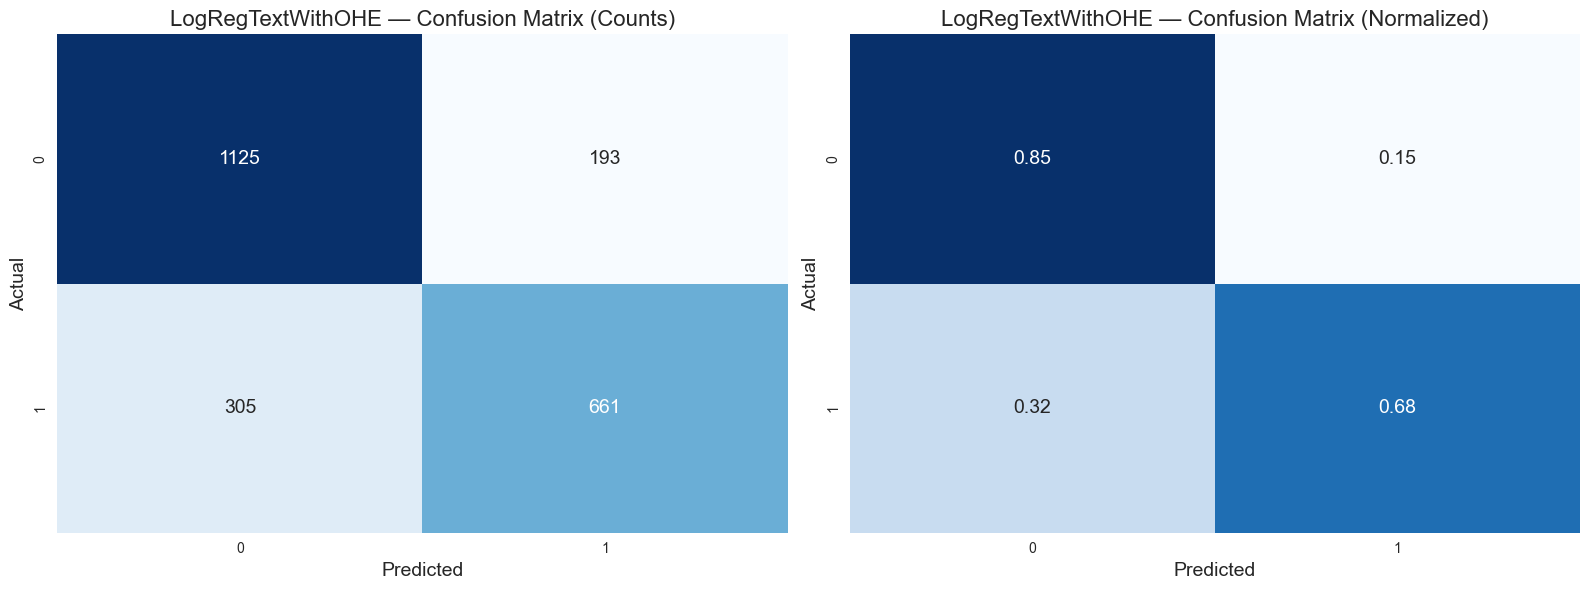

{'accuracy': 0.7819614711033275, 'precision': 0.7740046838407494, 'recall': 0.6842650103519669, 'f1': 0.7263736263736263}


In [68]:
metrics, y_pred = evaluator.eval(logreg_ohe, X_test_vec, y_test, model_name='LogRegTextWithOHE')

In [69]:
svc_ohe = SVC()

with Timer('SVC'):
    svc_ohe.fit(X_train_vec, y_train)

[SVC] Elapsed time: 15.9432 seconds


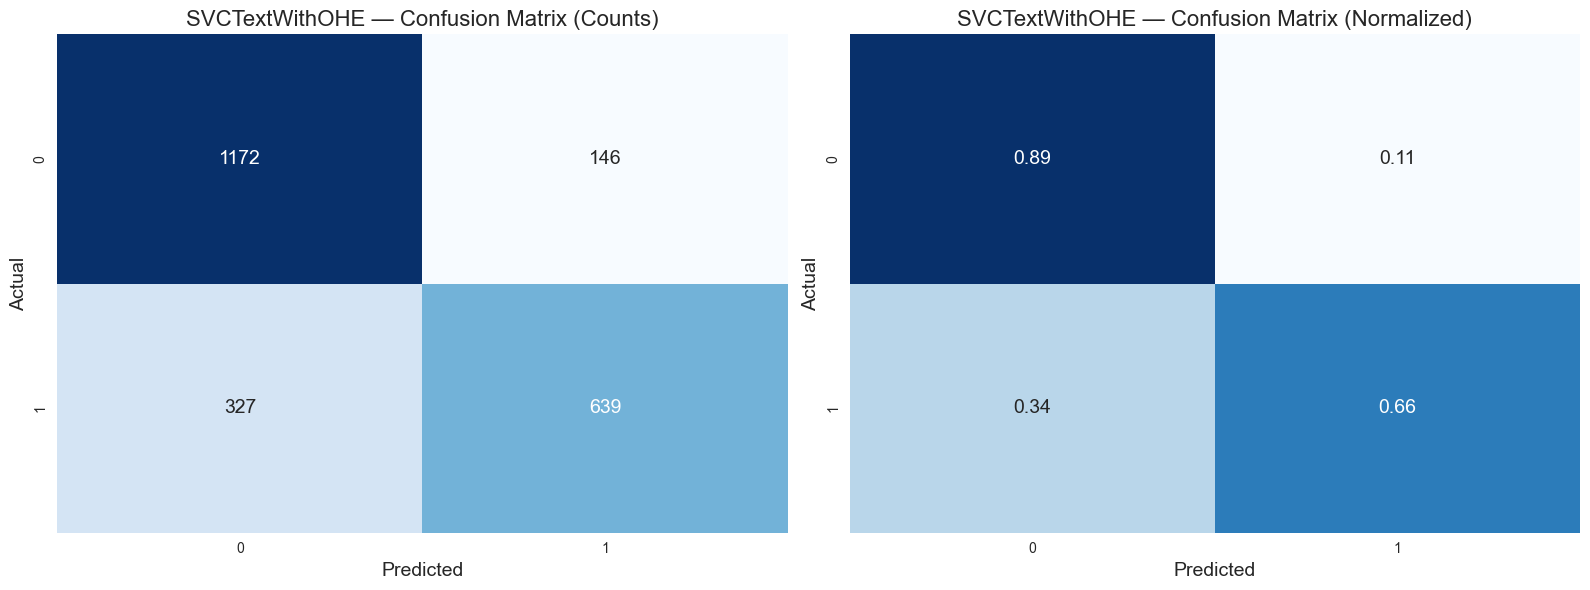

{'accuracy': 0.792907180385289, 'precision': 0.8140127388535032, 'recall': 0.6614906832298136, 'f1': 0.7298686464877213}


In [70]:
metrics, y_pred = evaluator.eval(svc_ohe, X_test_vec, y_test, model_name='SVCTextWithOHE')

In [71]:
evaluator.get_results()

,model,accuracy,precision,recall,f1
0,LogRegBaseline,0.790280,0.790226,0.686335,0.734626
1,SVCBaseline,0.794658,0.852482,0.622153,0.719330
2,LogRegRawTextReduced,0.779335,0.771765,0.679089,0.722467
3,SVCRawTextReduced,0.779335,0.771765,0.679089,0.722467
4,LogRegTextWithOHE,0.781961,0.774005,0.684265,0.726374
5,SVCTextWithOHE,0.792907,0.814013,0.661491,0.729869


## Интерпретация


- Качество осталось около 72% по f1-score для обеих моделей
- Для LogReg метрика precision (77%) осталась без изменений, одна она уменьшилась относительно SVC на сырых текстах (79%) без исключения части слов. По Recall отличия в рамках 1% 
- Для SVC подросла метрика precision (81%) против 77% на reduced, одна она уменьшилась относительно SVC на сырых текстах (85%) без исключения части слов. По Recall отличия только между первым случаем - оно выше на 4% относительно просто конкатенированных текстов.

Нельзя сказать, что мы получили какое-то существенное улучшение качества путем выделения категорий. Это может быть объяснено тем, что **присутствие токена категории - равноценно его кодированию с помощью ohe**


### **Задание 13. Улучшение базовых моделей путем подбора гиперпараметров. (1 балл).**
- Попробуйте подбирать разные гиперпараметры для логистической регрессии. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [72]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import BaseEstimator
from typing import Any, Optional, Union
import numpy as np
import pandas as pd


def cv_random(
    estimator: BaseEstimator,
    X: Union[pd.DataFrame, np.ndarray],
    y: Union[pd.DataFrame, np.ndarray],
    param_distributions: dict[str, Any],
    k: Optional[int] = 5,
    scoring: str = 'f1_score',
    n_iter: int = 100,
) -> tuple[BaseEstimator, dict[str, Any]]:
    rand_cv = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=k,
        random_state=42,
    )

    print('Fitting', str(estimator))
    print('Metric', scoring)
    print('n_iter =', n_iter)

    rand_cv.fit(X, y)

    print('Best parameters set found on train set:', rand_cv.best_params_)
    print('Total sampled models_num', n_iter)

    return rand_cv.best_estimator_, rand_cv.best_params_


# Обучение LogReg по Randomized Search

In [88]:
from sklearn.model_selection import RandomizedSearchCV

base_param_dist = {
    'penalty': [None, 'l1', 'l2', ],  # Меняем тип регуляризации
    'C': np.logspace(-4, 4, 200),  # широкий диапазон C
    'solver': ['lbfgs', 'liblinear'], 
    'max_iter': [100, 200, 300],
}

log_reg_cv, lr_cv_params = cv_random(
    LogisticRegression(),
    X_train_vec,
    y_train,
    param_distributions=base_param_dist,
    scoring='f1',
    k=2, # 1 Кроссвалидационная выборка
    n_iter=100,
)


Fitting LogisticRegression()
Metric f1
n_iter = 100


/Users/andrey/PycharmProjects/ai_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/andrey/PycharmProjects/ai_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/andrey/PycharmProjects/ai_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/andrey/PycharmProjects/ai_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1232: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/andrey/PycharmProjects/ai_machine_learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1232: Use

Best parameters set found on train set: {'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 100, 'C': 0.9547716114208056}
Total sampled models_num 100


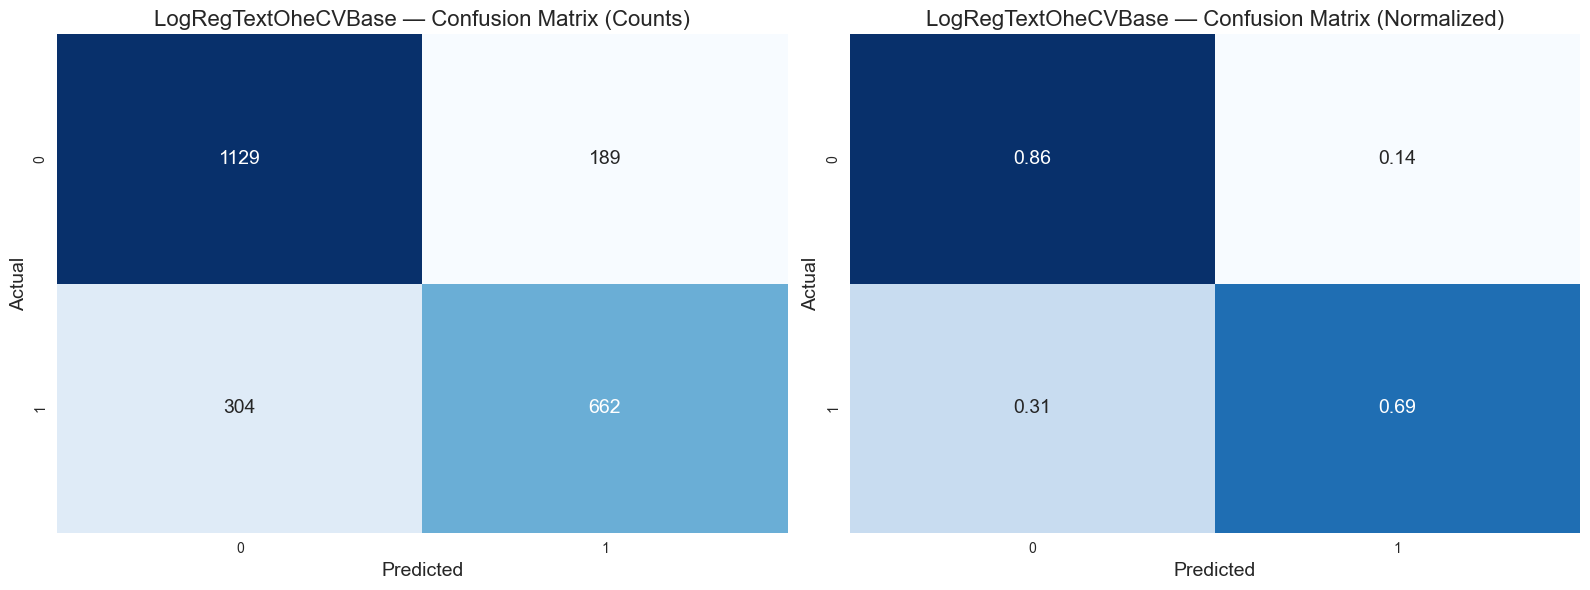

{'accuracy': 0.7841506129597198, 'precision': 0.7779083431257344, 'recall': 0.6853002070393375, 'f1': 0.728673637864612}


In [89]:
metrics, y_pred = evaluator.eval(log_reg_cv, X_test_vec, y_test, model_name='LogRegTextOheCVBase')

## Подбор гиперпараметров для LogReg

С помощью Randomized Search мы меняли 

1. Тип регуляризации: None, l1, l2
2. C - регулировал силу регуляризации
3. В качестве kernel использовали liblinear и стандартный


- Попробуйте подбирать разные гиперпараметры для модели SVC. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

## Базовый тюнинг SVC

In [91]:
param_distributions_svc = {
    'C': np.logspace(-3, 3, 50),  # штраф C
    'kernel': ['rbf', 'sigmoid'],
    # Параметры для kernel='rbf' и 'poly'
    'gamma': ['scale', 'auto'],
    'tol': [1e-3, 1e-4, 1e-5],
    'max_iter': [-1, 500, 1000],
}

svc_cv, svc_cv_params = cv_random(
    SVC(),
    X_train_vec,
    y_train,
    param_distributions=param_distributions_svc,
    scoring='f1',
    n_iter=10,  # а то до утра будем сидеть вычислять :)
    k=2,
)

Fitting SVC()
Metric f1
n_iter = 10


/Users/andrey/PycharmProjects/ai_machine_learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/andrey/PycharmProjects/ai_machine_learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/andrey/PycharmProjects/ai_machine_learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/andrey/PycharmProjects/ai_machine_learning/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with Standar

Best parameters set found on train set: {'tol': 0.001, 'max_iter': -1, 'kernel': 'rbf', 'gamma': 'scale', 'C': 3.5564803062231287}
Total sampled models_num 10


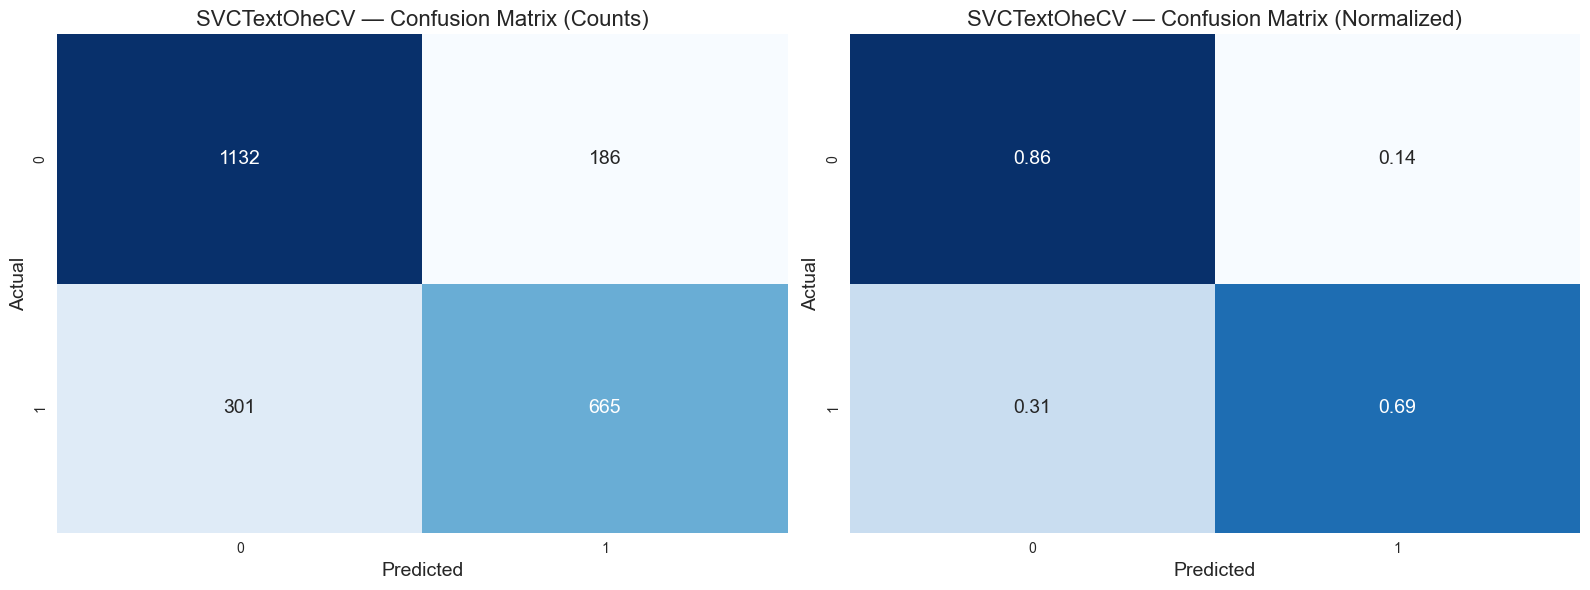

{'accuracy': 0.7867775831873906, 'precision': 0.781433607520564, 'recall': 0.6884057971014492, 'f1': 0.7319757842597688}


In [92]:
metrics, y_pred = evaluator.eval(svc_cv, X_test_vec, y_test, model_name='SVCTextOheCV')

# Подбор гиперпараметров для SVC

Для SVC делался минимальный k-fold разбиение, поскольку SVC - достаточно трудозатратный для вычислительных ресурсов алгоритм. Для него подбирались следующие параметры:

1. kernel - rbf (радиальная функция), sigmoid (сигмоида для ядер)
2. С - степень регуляризации
3. gamma - регулирует степень влияния отдельных ядер. Конкретные значения не тюнили ограничили встроеными методами (auto - 1/n_features, scale - 1/(n_features * X.var()) )
4. tol - Критерий ранней остановки
5. Кол-во итерация

По итогам получилась худшая метрика f1 при не самом большой precision. В таком случае кажется, что нужно ещё попробовать подбор других гиперпараметров или взять стандартные значения :)

# Общие выводы

## Саммари по подбору параметров

В рамках данного подбора гиперпараметров мы ограничили возможность их перебора некоторыми суб-алгоритмами для поиска локальных минимумов (LogReg ) и параметрами ядер для SVC. Это продиктована концепцией работы и ограниченностью времени работы на CPU.

Для дальнейшего улучшения LogReg можно попробовать другие solver (saga, newton-sg) и алгоритм для ядер в SVC

С помощью подбора гиперпараметров нам удалось получить лучшую SVC-модель по f1 (показатели ниже). LogisticRegression на OHE фичах незначительно улучшила свой результат относительно модели на тех же фичах без подбора (0.2% по f1)

Однако для logistic regression лучшие результат показала модель без тюнинга гиперпараметров, что странно. Возможно значения параметров были подобраны не оптимально 

## Саммари по моделям

### Логистическая регрессия

- Лучшая модель - бейзлайн на полной векторизации вместе с категориями (f1 = 73%) - она же строго по числам лучшая
- Вторая - на базе тюнинга гиперпараметров и OHE 

### SVC

- Лучшая модель получилась на OHE фичах с помощью подбора гиперпараметров
- Просто на OHE
- Другие оказались в конце списка

В целом, хочется отметить, что мы получили везде плюс минус похожий результат, однако есть модели, которые показывают явный перекос в сторону precision - `SVCBaseline` (f1- 72%, precision - 85%, recall - 62) - худшая модель 

Также несмотря на то, что бейзлайн LogReg показал лучший результат я бы выбрал Ohe для категорий - это более понятная история для бизнеса и для DS. 

In [94]:
evaluator.get_results()

,model,accuracy,precision,recall,f1
0,LogRegBaseline,0.790280,0.790226,0.686335,0.734626
1,SVCBaseline,0.794658,0.852482,0.622153,0.719330
2,LogRegRawTextReduced,0.779335,0.771765,0.679089,0.722467
3,SVCRawTextReduced,0.779335,0.771765,0.679089,0.722467
4,LogRegTextWithOHE,0.781961,0.774005,0.684265,0.726374
5,SVCTextWithOHE,0.792907,0.814013,0.661491,0.729869
6,LogRegTextOheCVBase,0.784151,0.777908,0.685300,0.728674
7,SVCTextOheCV,0.786778,0.781434,0.688406,0.731976


### **Задание 14. (0.5 балла)**

Оформите два [пайплайна](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html):
- для модели регрессии
- для SVC модели

в пайплайн должны входить предобработка сырого датасета и обучение модели. 

In [100]:
from sklearn.pipeline import Pipeline

log_reg_pipe = Pipeline(
    steps=[
        ('transformer', col_transformer),
        ('classifier', LogisticRegression()),
    ],
)

log_reg_pipe.fit(X_train, y_train)

print('Accuracy: ', log_reg_pipe.score(X_test, y_test))

Accuracy:  0.7819614711033275


In [101]:
svc_pipe = Pipeline(
    steps=[
        ('transformer', col_transformer),
        ('classifier', SVC(**svc_cv_params)),
    ],
)

svc_pipe.fit(X_train, y_train)


print('Accuracy: ', svc_pipe.score(X_test, y_test))

Accuracy:  0.7867775831873906


**Опишите общие мысли о работе. Это место для вашей рефлексии, не обязательное, но полезное.**  🐤


1. Надо пробовать другие модели -  NaiveBayes и прочее, но пока по срокам не получилось :)
2. Не очень хотелось категории загонять под CountVectorizer - это неочевидно, хотя и оказалось довольно эффективно. Фича в целом не потерялась. Но с tf-idf такая шутка не прошла бы